# Gesture CNN-LSTM


In [1]:
from __future__ import annotations

import json
import sys
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import DataLoader


def find_repo_root() -> Path:
    p = Path.cwd().resolve()
    for _ in range(8):
        if (p / "ml" / "gesture_lstm" / "dataset.py").is_file():
            return p
        p = p.parent
    raise RuntimeError("Откройте ноутбук из репозитория KinestheticBook.")


REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from ml.gesture_lstm.dataset import GestureNoiseDataset, NormalizedSubset, SubsetDataset, compute_norm_stats, stratified_split
from ml.gesture_lstm.focal_loss import FocalLoss
from ml.gesture_lstm.model import GestureCNNLSTM, GestureLSTM

print(REPO_ROOT)
print(torch.__version__, "cuda" if torch.cuda.is_available() else "cpu")


/home/doctorstone/Документы/KinestheticBook
2.11.0+cpu cpu


In [2]:
DATA_DIR = REPO_ROOT / "ml" / "dataset" / "data"
OUT_DIR = REPO_ROOT / "ml" / "gesture_lstm" / "runs" / "notebook"
OUT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_TYPE = "cnn_lstm"  # "cnn_lstm" или "lstm"
SEQ_LEN = 64
GRID_DT = 0.05
NOISE_WINDOW = 48
NOISE_STRIDE = 24
MAX_NOISE_SAMPLES = 400

HIDDEN = 64
CNN_CHANNELS = 128
LSTM_LAYERS = 1
DROPOUT = 0.25
EPOCHS = 80
BATCH_SIZE = 16
LR = 1e-3
VAL_RATIO = 0.2
SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.manual_seed(SEED)
np.random.seed(SEED)

FOCAL_GAMMA = 2.0


In [3]:
full_ds = GestureNoiseDataset(
    DATA_DIR,
    seq_len=SEQ_LEN,
    grid_dt=GRID_DT,
    noise_window_rows=NOISE_WINDOW,
    noise_stride=NOISE_STRIDE,
    max_noise_samples=MAX_NOISE_SAMPLES,
    seed=SEED,
)

counts = Counter(y for _, y, _ in full_ds.samples)
print("samples:", len(full_ds))
print("labels:", full_ds.label_to_idx)
for i, n in sorted(counts.items()):
    print(f"{full_ds.idx_to_label[i]}: {n}")


samples: 64
labels: {'bye': 0, 'hello': 1, 'propeller': 2, 'осуждаем': 3, 'поршневой-режим': 4, '__noise__': 5}
bye: 8
hello: 10
propeller: 6
осуждаем: 10
поршневой-режим: 4
__noise__: 26


In [4]:
train_idx, val_idx = stratified_split(full_ds, val_ratio=VAL_RATIO, seed=SEED)
mean, std = compute_norm_stats(full_ds, train_idx)
np.savez(OUT_DIR / "norm.npz", mean=mean, std=std)

train_ds = NormalizedSubset(SubsetDataset(full_ds, train_idx, augment=True), mean, std)
train_ds_eval = NormalizedSubset(SubsetDataset(full_ds, train_idx, augment=False), mean, std)
val_ds = NormalizedSubset(SubsetDataset(full_ds, val_idx, augment=False), mean, std)
loader_train = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
loader_train_eval = DataLoader(train_ds_eval, batch_size=BATCH_SIZE, shuffle=False)
loader_val = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

n_classes = full_ds.num_classes()
if MODEL_TYPE == "cnn_lstm":
    model = GestureCNNLSTM(len(mean), CNN_CHANNELS, HIDDEN, LSTM_LAYERS, n_classes, DROPOUT)
else:
    model = GestureLSTM(len(mean), HIDDEN, LSTM_LAYERS, n_classes, DROPOUT)
model = model.to(DEVICE)

opt = torch.optim.Adam(model.parameters(), lr=LR)
y_train = np.array([full_ds.samples[i][1] for i in train_idx], dtype=np.int64)
cw = compute_class_weight("balanced", classes=np.arange(n_classes), y=y_train)
class_weight = torch.tensor(cw, dtype=torch.float32, device=DEVICE)

crit = FocalLoss(weight=class_weight, gamma=FOCAL_GAMMA).to(DEVICE)

print("train:", len(train_idx), "val:", len(val_idx), "classes:", n_classes)
print("class weights (balanced - F.cross_entropy weight=):", {full_ds.idx_to_label[i]: round(float(cw[i]), 3) for i in range(n_classes)})
print("loss: FocalLoss  gamma=", FOCAL_GAMMA, "  class_weight shape:", tuple(crit.class_weight.shape))


train: 51 val: 13 classes: 6
class weights (balanced - F.cross_entropy weight=): {'bye': 1.417, 'hello': 1.062, 'propeller': 1.7, 'осуждаем': 1.062, 'поршневой-режим': 2.833, '__noise__': 0.405}
loss: FocalLoss  gamma= 2.0   class_weight shape: (6,)


In [5]:
hist_train_loss: list[float] = []
hist_val_loss: list[float] = []
hist_train_f1: list[float] = []
hist_val_f1: list[float] = []


@torch.no_grad()
def macro_f1(loader) -> float:
    model.eval()
    ys: list[int] = []
    ps: list[int] = []
    for x, y in loader:
        ys.extend(y.numpy().tolist())
        ps.extend(model(x.to(DEVICE)).argmax(1).cpu().numpy().tolist())
    if not ys:
        return 0.0
    return float(f1_score(ys, ps, average="macro", zero_division=0))


best_f1 = -1.0
best_state = None

for epoch in range(1, EPOCHS + 1):
    model.train()
    total = 0
    loss_sum = 0.0
    for x, y in loader_train:
        x, y = x.to(DEVICE), y.to(DEVICE)
        opt.zero_grad()
        logits = model(x)
        loss = crit(logits, y)
        loss.backward()
        opt.step()

        loss_sum += loss.item() * x.size(0)
        total += x.size(0)

    model.eval()
    v_total = 0
    v_loss = 0.0
    with torch.no_grad():
        for x, y in loader_val:
            x, y = x.to(DEVICE), y.to(DEVICE)
            logits = model(x)
            loss = crit(logits, y)
            v_loss += loss.item() * x.size(0)
            v_total += x.size(0)

    train_loss = loss_sum / max(total, 1)
    val_loss = v_loss / max(v_total, 1)
    train_f1 = macro_f1(loader_train_eval)
    val_f1 = macro_f1(loader_val)

    hist_train_loss.append(train_loss)
    hist_val_loss.append(val_loss)
    hist_train_f1.append(train_f1)
    hist_val_f1.append(val_f1)

    if epoch == 1 or epoch % max(1, EPOCHS // 10) == 0 or epoch == EPOCHS:
        print(f"{epoch:03d}: focal {train_loss:.4f}/{val_loss:.4f}  macro-F1 {train_f1:.3f}/{val_f1:.3f}")

    if v_total and val_f1 > best_f1:
        best_f1 = val_f1
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

model.load_state_dict(best_state or model.state_dict())
print("best val macro-F1:", best_f1)


001: focal 1.3481/1.4123  macro-F1 0.208/0.024
008: focal 0.6345/0.8031  macro-F1 0.644/0.617
016: focal 0.2293/0.5124  macro-F1 0.756/0.706
024: focal 0.2225/0.3212  macro-F1 0.818/0.792
032: focal 0.2480/0.1719  macro-F1 0.777/0.784
040: focal 0.1089/0.0747  macro-F1 0.782/0.784
048: focal 0.1557/0.2334  macro-F1 0.739/0.706
056: focal 0.0864/0.1277  macro-F1 0.831/0.784
064: focal 0.1360/0.0688  macro-F1 0.887/0.784
072: focal 0.1838/0.2378  macro-F1 0.802/0.562
080: focal 0.0617/0.0518  macro-F1 0.855/0.812
best val macro-F1: 0.9481481481481481


                 precision    recall  f1-score   support

            bye       1.00      1.00      1.00         2
          hello       0.67      1.00      0.80         2
      propeller       1.00      1.00      1.00         1
       осуждаем       1.00      1.00      1.00         2
поршневой-режим       1.00      1.00      1.00         1
      __noise__       1.00      0.80      0.89         5

       accuracy                           0.92        13
      macro avg       0.94      0.97      0.95        13
   weighted avg       0.95      0.92      0.93        13



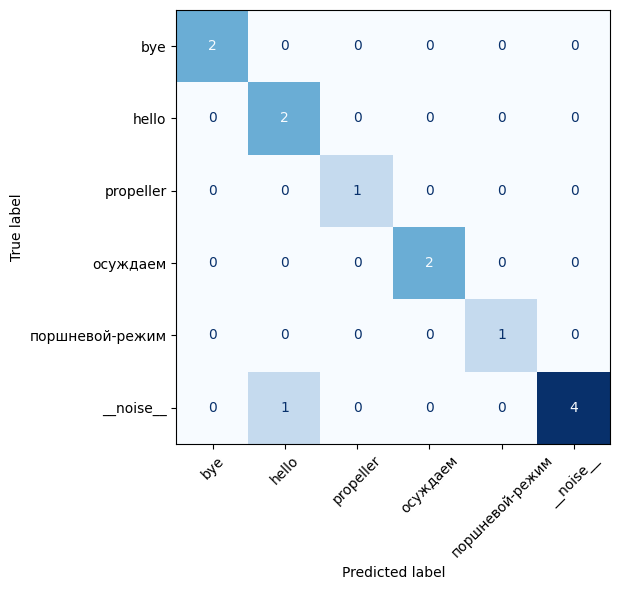

In [6]:
model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for x, y in loader_val:
        pred = model(x.to(DEVICE)).argmax(1).cpu().numpy().tolist()
        y_pred.extend(pred)
        y_true.extend(y.numpy().tolist())

labels = list(range(n_classes))
names = [full_ds.idx_to_label[i] for i in labels]

if y_true:
    print(classification_report(y_true, y_pred, labels=labels, target_names=names, zero_division=0))
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    fig, ax = plt.subplots(figsize=(max(6, n_classes * 1.3), max(5, n_classes)))
    ConfusionMatrixDisplay(cm, display_labels=names).plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
    ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("Validation split is empty.")


In [7]:
ckpt = {
    "model_state": model.state_dict(),
    "config": {
        "model_type": MODEL_TYPE,
        "n_features": int(len(mean)),
        "hidden_size": HIDDEN,
        "cnn_channels": CNN_CHANNELS if MODEL_TYPE == "cnn_lstm" else None,
        "num_layers": LSTM_LAYERS,
        "num_classes": n_classes,
        "dropout": DROPOUT,
        "seq_len": SEQ_LEN,
        "grid_dt": GRID_DT,
    },
    "label_to_idx": full_ds.label_to_idx,
}
torch.save(ckpt, OUT_DIR / "checkpoint.pt")
full_ds.export_label_map(OUT_DIR / "label_map.json")

meta = {
    "data_dir": str(DATA_DIR.resolve()),
    "n_samples": len(full_ds),
    "n_train": len(train_idx),
    "n_val": len(val_idx),
    "classes": full_ds.label_to_idx,
    "model_type": MODEL_TYPE,
    "grid_dt": GRID_DT,
}
(OUT_DIR / "run_meta.json").write_text(json.dumps(meta, indent=2, ensure_ascii=False), encoding="utf-8")
print("saved to", OUT_DIR)


saved to /home/doctorstone/Документы/KinestheticBook/ml/gesture_lstm/runs/notebook


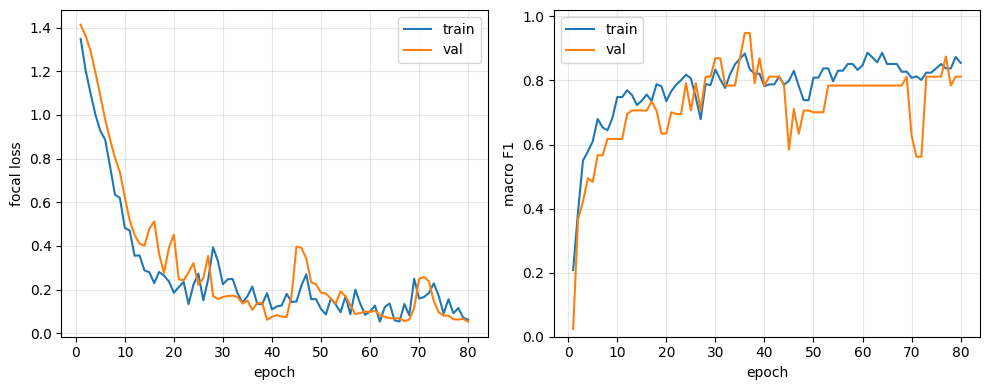

In [8]:
if not hist_train_loss:
    raise RuntimeError("Сначала выполните ячейку с обучением.")

ep = np.arange(1, len(hist_train_loss) + 1)
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(10, 4))
ax0.plot(ep, hist_train_loss, label="train")
ax0.plot(ep, hist_val_loss, label="val")
ax0.set_xlabel("epoch")
ax0.set_ylabel("focal loss")
ax0.legend()
ax0.grid(True, alpha=0.3)
ax1.plot(ep, hist_train_f1, label="train")
ax1.plot(ep, hist_val_f1, label="val")
ax1.set_xlabel("epoch")
ax1.set_ylabel("macro F1")
ax1.set_ylim(0.0, 1.02)
ax1.legend()
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
